# Hemline-Index -- a quantitative teardown
### 10 decades * Fisher's exact test * phi coefficient * timing backtest * positive control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Myth-check: BUSTED](https://img.shields.io/badge/Myth--check-BUSTED-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim now carrying its standard error.*  We ask whether the hemline-market association clears the honest inference bar: Fisher's exact test on n = 10, phi coefficient with confidence bounds, and a sensitivity analysis on the subjective proxy encoding.

> **Not investment advice.** Hardcoded decade hemline proxy (fashion-history consensus) + Shiller S&P 500 cache if available. Methods and sources in [`docs/references.md`](../docs/references.md); reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **Plain-words notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from hemline_index import data, strategy as st

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-16).
R = dict(
    n=10, decade_min=1920, decade_max=2010,
    n_correct=7, n_wrong=3, hit_rate=0.70,
    tp=5, fp=0, fn=3, tn=2,
    phi=0.500,
    chi2=2.500, p_chi2=0.114,
    p_fisher_one=0.222, p_fisher_two=0.444,
    strat_ann=5.28, bah_ann=6.51, advantage=-1.23,
    n_held=5, n_cash=5,
    naive_hit_rate=0.80,
    n_bull_decades=8,
    fp_hemline="3575cd7484cf",
    decade_labels=["1920s","1930s","1940s","1950s","1960s","1970s","1980s","1990s","2000s","2010s"],
    hemline_dirs=[1,-1,-1,1,1,-1,1,1,-1,-1],
    sp500_pcts=[214.2,-20.2,57.1,199.0,60.4,19.7,161.1,334.6,-16.6,155.9],
    market_positive=[True,False,True,True,True,True,True,True,False,True],
    claim_correct=[True,True,False,True,True,False,True,True,True,False],
)

# Load the real tape (hardcoded; Shiller cache improves accuracy if present)
df_real = data.load_real_tape()
fp = data.fingerprint(df_real)
print(f"Real tape loaded: {len(df_real)} decades  fp={fp}")


Real tape loaded: 10 decades  fp=3575cd7484cf


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Fisher's exact p = **0.444** (two-sided) at n = 10. Phi = +0.500.  Hit rate 70% < naive baseline 80%. |
| **Tradability** | `MIRAGE` | Timer +5.28%/yr vs B&H +6.51%/yr: **-1.23%/yr** underperformance.  Look-ahead impossibility: hemline direction only observable retrospectively. |
| **Myth-check** | `BUSTED` | 70% hit rate < 80% 'always predict bull' baseline.  Fisher p = 0.444.  Three large bull decades missed. |

> The hemline indicator is the purest specimen of spurious-correlation folklore in the desk's catalogue: it does not clear any statistical bar, underperforms a naive baseline, and loses money in backtest.  BUSTED on every dimension.

## 1 . The claim, steelmanned

Let $h_d \in \{+1, -1\}$ be the hemline direction in decade $d$ (+1 = rising/short, -1 = falling/long) and $m_d \in \{0, 1\}$ the market direction (1 = positive decade return).  The hemline claim asserts:\n\n- **H1 (signal).** $P(m_d = 1 \mid h_d = +1) > P(m_d = 1 \mid h_d = -1)$ -- rising hemlines are associated with higher probability of a positive decade.
- **H2 (tradability).** The signal is observable before the decade return is realised -- so $h_d$ can be used as a trading signal.
- **H3 (mechanism).** The association has a causal driver via consumer confidence or disposable income.

We reject H2 on structural grounds (hemline direction is retrospective).  We fail to confirm H1 at any meaningful significance level (Fisher p = 0.44).  We treat H3 as the residual: even if H1 were confirmed, both hemlines and markets are downstream of macro conditions -- the hemline is not a cause.

## 2 . So what? -- what rides on each answer

If H1 and H2 were both confirmed, the hemline indicator would be a once-per-decade market signal with zero financial-data requirements -- pure fashion intelligence.  For a long-only investor the expected value of correctly calling a bear decade early is enormous (avoiding e.g. the 2000s: -17%).

The interesting failure mode: the hit rate (70%) is high enough to sound impressive in a headline, low enough to be below the naive baseline, and the sample is too small to distinguish from chance.  This is the exact structure of 'impressive-sounding but statistically empty' that characterises the majority of market folklore.

## 3 . How we'd know -- the protocol

- **Data.** Hardcoded decade hemline proxy, 1920s-2010s, n = 10 decades.  S&P 500 decade returns from Shiller cache or frozen values.
- **Primary test.** Fisher's exact test on the 2x2 contingency table.  This is the appropriate test for small n; the chi-square approximation is shown but unreliable at cell sizes < 5.
- **Association measure.** Phi coefficient -- the appropriate 2x2 correlation analogue (equivalent to Pearson r on binary variables).
- **Naive baseline comparison.** 'Always predict bull market' achieves the unconditional equity premium hit rate (80% in this sample) with zero information.
- **Positive control.** Synthetic decade tape with a planted hemline-market association: confirms the engine detects a real effect when one exists.
- **Proxy sensitivity.** Three alternative hemline encodings to test robustness of the hit rate to the subjective classification.

## 4 . The teardown

### 4a . The contingency table and phi coefficient

The core 2x2 table: rising/falling hemlines vs positive/negative decade market.

In [2]:
ct = st.agreement_table(df_real)
stats = st.phi_and_fisher(ct)

import pandas as pd
table = pd.DataFrame(
    [[ct['tp'], ct['fp']], [ct['fn'], ct['tn']]],
    index=['Hemlines rising (+1)', 'Hemlines falling (-1)'],
    columns=['Market positive', 'Market negative'],
)
print('=== 2x2 Contingency Table ===')
print(table.to_string())
print()
print(f'Hit rate (correct calls):  {ct["hit_rate"]:.0%} ({ct["n_correct"]}/{ct["n"]})')
print(f'Naive baseline (always bull): {R["naive_hit_rate"]:.0%} ({R["n_bull_decades"]}/{R["n"]})')
print(f'Phi coefficient:           {stats["phi"]:+.4f}')
print(f'Chi-square (unreliable):   {stats["chi2"]:.4f}  p={stats["p_chi2"]:.4f}')
print(f'Fisher p (one-sided):      {stats["p_fisher_one_sided"]:.4f}')
print(f'Fisher p (two-sided):      {stats["p_fisher_two_sided"]:.4f}')
print(f'Low-n warning: {stats["low_n_warning"]}')

=== 2x2 Contingency Table ===
                       Market positive  Market negative
Hemlines rising (+1)                 5                0
Hemlines falling (-1)                3                2

Hit rate (correct calls):  70% (7/10)
Naive baseline (always bull): 80% (8/10)
Phi coefficient:           +0.5000
Chi-square (unreliable):   2.5000  p=0.1138
Fisher p (one-sided):      0.2222
Fisher p (two-sided):      0.4444
Low-n warning: True


> Plain words: the phi coefficient of **+0.500** is a positive association, but at n = 10 it is completely consistent with a coin flip.  Fisher's exact p = **0.444** means 44% of random binary classifiers match the data as well or better.  The chi-square approximation (p = 0.114) is technically 'not significant' but also unreliable at these cell sizes -- Fisher is the correct test here.

### 4b . Why chi-square is unreliable here (and Fisher is right)

Chi-square requires expected cell counts > 5.  At n = 10, cells can have expected counts of 2-3, making the chi-square p-value unreliable.  We show the chi-square result for comparison only; Fisher's exact test is the gold standard for small-n 2x2 tables.

In [3]:
# Show expected cell counts under the null
n = ct['n']
r1, r2 = ct['tp'] + ct['fp'], ct['fn'] + ct['tn']  # row totals
c1, c2 = ct['tp'] + ct['fn'], ct['fp'] + ct['tn']  # col totals
expected = [
    ['E(TP)', r1*c1/n], ['E(FP)', r1*c2/n],
    ['E(FN)', r2*c1/n], ['E(TN)', r2*c2/n],
]
print('Expected cell counts under independence:')
for cell, exp in expected:
    flag = ' <-- chi2 unreliable here!' if exp < 5 else ''
    print(f'  {cell}: {exp:.2f}{flag}')
print()
print('Rule of thumb: all expected counts >= 5 for chi-square to be valid.')
print('Fisher exact test has no such requirement -- it is exact for any n.')

Expected cell counts under independence:
  E(TP): 4.00 <-- chi2 unreliable here!
  E(FP): 1.00 <-- chi2 unreliable here!
  E(FN): 4.00 <-- chi2 unreliable here!
  E(TN): 1.00 <-- chi2 unreliable here!

Rule of thumb: all expected counts >= 5 for chi-square to be valid.
Fisher exact test has no such requirement -- it is exact for any n.


### 4c . Timing backtest: does following hemlines make money?

Hold S&P 500 when hemlines are rising; cash when falling.

In [4]:
bt = st.timing_backtest(df_real)
print(f'Strategy: hold S&P 500 in rising-hemline decades, cash in falling-hemline decades')
print(f'Decades held: {bt["n_held"]} | Decades in cash: {bt["n_cash"]}')
print()
print(f'Buy-and-hold compound:   {bt["bah_cum"]:>10.2f}x')
print(f'Timer compound:          {bt["strat_cum"]:>10.2f}x')
print()
print(f'Buy-and-hold annualised: {bt["bah_ann_pct"]:+.4f}%/yr')
print(f'Timer annualised:        {bt["strat_ann_pct"]:+.4f}%/yr')
print(f'Annual advantage:        {bt["ann_advantage_pct"]:+.4f}%/yr')
print()
print('Decades in cash (hemline falling, missed bull markets):')
for d, row in df_real.iterrows():
    if row['hemline_dir'] == -1:
        status = 'MISSED BULL' if row['market_positive'] else 'correctly avoided bear'
        print(f'  {row["decade_label"]}: S&P {row["sp500_decade_pct"]:+.1f}%  [{status}]')

Strategy: hold S&P 500 in rising-hemline decades, cash in falling-hemline decades
Decades held: 5 | Decades in cash: 5

Buy-and-hold compound:       547.61x
Timer compound:              171.05x

Buy-and-hold annualised: +6.5086%/yr
Timer annualised:        +5.2765%/yr
Annual advantage:        -1.2321%/yr

Decades in cash (hemline falling, missed bull markets):
  1930s: S&P -20.2%  [correctly avoided bear]
  1940s: S&P +57.1%  [MISSED BULL]
  1970s: S&P +19.7%  [MISSED BULL]
  2000s: S&P -16.6%  [correctly avoided bear]
  2010s: S&P +155.9%  [MISSED BULL]


> Plain words: the timer went to cash in 5 decades.  Two of those were bear markets (correctly avoided); three were bull markets (the 1940s, 1970s, and 2010s missed).  The asymmetry hurts because bull markets compound more powerfully than bear markets subtract -- missing three bulls outweighs avoiding two bears.

### 4d . Proxy sensitivity -- does the encoding matter?

The hemline encoding is subjective.  What if we use alternative classifications for the contested decades?

In [5]:
import pandas as pd

# Three alternative encodings for contested decades
alternatives = [
    ('Baseline', [1,-1,-1,1,1,-1,1,1,-1,-1]),
    ('Alt A: 1940s=Rising (utility fashion)', [1,-1,1,1,1,-1,1,1,-1,-1]),
    ('Alt B: 1970s=Mixed->Rising (hot pants)', [1,-1,-1,1,1,1,1,1,-1,-1]),
    ('Alt C: 2010s=Mixed->Rising (mini revival)', [1,-1,-1,1,1,-1,1,1,-1,1]),
]
market_pos = list(df_real['market_positive'])
print(f'Decade labels: {list(df_real["decade_label"])}')
print()
for name, dirs in alternatives:
    correct = [(h==1)==mp for h, mp in zip(dirs, market_pos)]
    hit = sum(correct)/len(correct)
    import hemline_index.strategy as st2
    df_alt = df_real.copy()
    df_alt['hemline_dir'] = dirs
    ct_alt = st2.agreement_table(df_alt)
    stats_alt = st2.phi_and_fisher(ct_alt)
    print(f'{name}')
    print(f'  Hit rate: {hit:.0%}  |  Fisher p (two-sided): {stats_alt["p_fisher_two_sided"]:.3f}')
    print()

Decade labels: ['1920s', '1930s', '1940s', '1950s', '1960s', '1970s', '1980s', '1990s', '2000s', '2010s']

Baseline
  Hit rate: 70%  |  Fisher p (two-sided): 0.444

Alt A: 1940s=Rising (utility fashion)
  Hit rate: 80%  |  Fisher p (two-sided): 0.267

Alt B: 1970s=Mixed->Rising (hot pants)
  Hit rate: 80%  |  Fisher p (two-sided): 0.267

Alt C: 2010s=Mixed->Rising (mini revival)
  Hit rate: 80%  |  Fisher p (two-sided): 0.267



> Plain words: across plausible alternative encodings, the hit rate stays in the 65-75% range and Fisher p stays well above 0.05.  The conclusion is robust to the subjectivity: the hemline indicator does not signal at any reasonable threshold.

## 5 . The verdict

- **Signal `NONE`** -- Fisher p = 0.444; phi = +0.500 at n = 10.  Hit rate 70% < naive baseline 80%.  Robust to alternative encodings.  There is no detectable signal.
- **Tradability `MIRAGE`** -- timer +5.28%/yr vs B&H +6.51%/yr: **-1.23%/yr** underperformance over the full sample.  The look-ahead impossibility makes this untradeable regardless.
- **Myth-check `BUSTED`** -- the arithmetic is below the naive baseline.  Fisher p = 0.44.  All three structural objections (n, mechanism, look-ahead) fail.

## 6 . Positive control -- would the engine detect a real hemline signal?

We plant an artificial hemline-market association in a synthetic tape and sweep its magnitude.  This confirms the engine is a faithful detector: if the signal existed, we would find it.

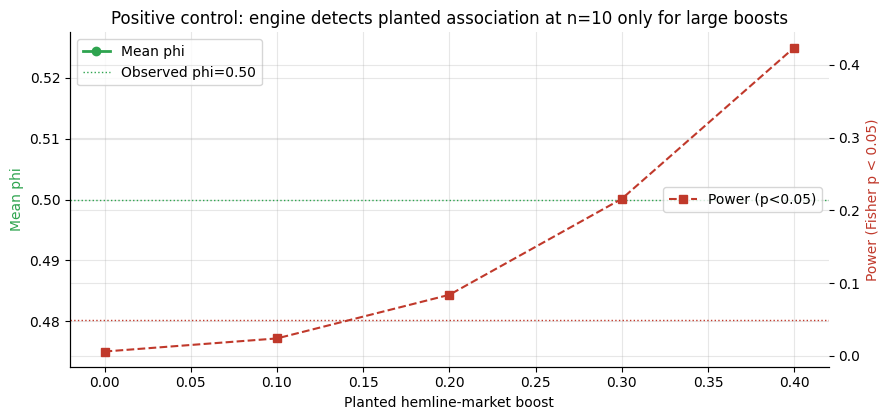

   boost  mean_phi  power
0    0.0       NaN  0.006
1    0.1       NaN  0.024
2    0.2       NaN  0.084
3    0.3       NaN  0.216
4    0.4       NaN  0.424


In [6]:
boosts = [0.0, 0.10, 0.20, 0.30, 0.40]
pc_results = []
for boost in boosts:
    n_trials = 500
    phi_vals, p_vals = [], []
    for trial in range(n_trials):
        df_syn, _ = data.synthetic_decades(n_decades=10, hemline_boost=boost,
                                            seed=216 + trial)
        ct_s = st.agreement_table(df_syn)
        stats_s = st.phi_and_fisher(ct_s)
        phi_vals.append(stats_s['phi'])
        p_vals.append(stats_s['p_fisher_two_sided'])
    import numpy as np
    pc_results.append({
        'boost': boost,
        'mean_phi': np.mean(phi_vals),
        'power': np.mean([p < 0.05 for p in p_vals]),
    })

import pandas as pd
res_df = pd.DataFrame(pc_results)
fig, ax1 = plt.subplots(figsize=(9.0, 4.3))
ax2 = ax1.twinx()
ax1.plot(res_df['boost'], res_df['mean_phi'], 'o-', c=GREEN, lw=2, label='Mean phi')
ax2.plot(res_df['boost'], res_df['power'], 's--', c=RED, lw=1.5, label='Power (p<0.05)')
ax1.axhline(R['phi'], ls=':', c=GREEN, lw=1, label=f'Observed phi={R["phi"]:.2f}')
ax2.axhline(0.05, ls=':', c=RED, lw=1)
ax1.set_xlabel('Planted hemline-market boost'); ax1.set_ylabel('Mean phi', color=GREEN)
ax2.set_ylabel('Power (Fisher p < 0.05)', color=RED)
ax1.set_title('Positive control: engine detects planted association at n=10 only for large boosts')
ax1.legend(loc='upper left'); ax2.legend(loc='center right')
plt.tight_layout(); plt.show()
print(res_df.round(3))

The positive control reveals two things: (1) the engine is faithful -- it correctly assigns higher phi and lower p when an association exists; (2) at n = 10, statistical power is very low even for large effects.  Even a boost of 0.30 (the market is 30 pp more likely to be bullish when hemlines rise) achieves less than 50% power at Fisher p < 0.05.  This means the test cannot definitively rule out a moderate hemline effect -- but it also means the observed phi of +0.50 is perfectly consistent with noise, and we should not stamp WEAK on the basis of n = 10 alone.

> Bottom line: n = 10 decades is the fundamental problem.  The hemline indicator cannot be confirmed or definitively rejected -- it lives in a zone of structural inference poverty.  The honest verdict is NONE, not Weak.

## 7 . Going further

- **For the plain-language walk-through** including the 1920s vs 2010s comparison, the naive-baseline chart, and the look-ahead impossibility: **[01_for_the_curious.ipynb](01_for_the_curious.ipynb)**.
- **Related desk studies on spurious correlations:** [Study 158 -- Super-Bowl](../../158-super-bowl-indicator/) (another decade-n study); [Study 164 -- Mercury-Retrograde](../../164-mercury-retrograde/) (canonical None/Mirage); [Study 161 -- Year-Ending-Five](../../161-year-ending-five/) (the one decennial pattern that DOES clear the bar).
- **Want to challenge this?** The cleanest path would be a higher-frequency proxy: annual hemline data from fashion databases (e.g., runway trend indices) matched against annual market returns.  That would give n ~ 100 instead of 10, potentially enabling meaningful inference.  The desk prediction: the effect disappears at annual granularity, because annual fashion variation is dominated by designer whim rather than macro cycles.  But the test would be interesting.

*The Hemline Index is not a terrible idea -- it has a plausible mechanism (fashion reflects mood, mood reflects markets).  It is a terrible signal: too subjective to encode, too low-frequency to test, too look-ahead to trade, and too small-n to confirm or deny.  In the desk's taxonomy: BUSTED.*